 ## About Data

### Description:
This synthetic dataset is designed to help beginners and intermediate learners practice data cleaning and analysis in a realistic setting. It simulates a student tracking system, covering key areas like:

* Attendance tracking
* Homework completion
* Exam performance
* Parent-teacher communication

### Why Use This Dataset?
While many datasets are pre-cleaned, real-world data is often messy. This dataset includes intentional errors to help you develop essential data cleaning skills before diving into analysis. It’s perfect for building confidence in handling raw data!

### Cleaning Challenges You’ll Tackle
This dataset is packed with real-world issues, including:

* Messy data: Names in lowercase, typos in attendance status.
* Inconsistent date formats: Mix of MM/DD/YYYY and YYYY-MM-DD.
* Incorrect values: Homework completion rates in mixed formats (e.g., 80% and 90).
* Missing data: Guardian signatures, teacher comments, and emergency contacts.
* Outliers: Exam scores over 100 and negative homework completion rates

https://www.kaggle.com/datasets/marvyaymanhalim/student-performance-and-attendance-dataset

In [3]:
# Imports
import pandas as pd
import numpy as np

In [107]:
#load data
data1= pd.read_csv("attendance.csv")
data2=pd.read_csv("performance.csv")

main_data=pd.merge(data1,data2,on="Student_ID")

## Data Overview

In [108]:
#Viewing first entries of the data
main_data.head()

,Student_ID,Date,Subject_x,Attendance_Status,Subject_y,Exam_Score,Homework_Completion_%,Teacher_Comments
0,S06592,2024-09-20,Arabic,Present,Math,64,100%,
1,S06592,2024-09-20,Arabic,Present,Math,83,-5,
2,S01777,2025-01-22,Math,Present,Geography,69,-5,Soon no hit leg year next boy.
3,S01777,2025-01-22,Math,Present,English,88,95,
4,S01777,2025-01-22,Math,Present,Arabic,66,80%,Number she contain gun within magazine program.


- The dataset contains student information, including marks and classroom performance.
- Some entries in Homework_Completion_% contain negative percentages, which need to be corrected

In [109]:
# number of entries and featues
main_data.shape

(1094318, 8)

- The data includes around 1,000,000 students, each with 8 recorded features.

In [110]:
#column types and general feature info
main_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094318 entries, 0 to 1094317
Data columns (total 8 columns):
 #   Column                 Non-Null Count    Dtype 
---  ------                 --------------    ----- 
 0   Student_ID             1094318 non-null  object
 1   Date                   1094318 non-null  object
 2   Subject_x              1094318 non-null  object
 3   Attendance_Status      1094318 non-null  object
 4   Subject_y              1094318 non-null  object
 5   Exam_Score             1094318 non-null  int64 
 6   Homework_Completion_%  1094318 non-null  object
 7   Teacher_Comments       1094318 non-null  object
dtypes: int64(1), object(7)
memory usage: 66.8+ MB


- Our data does not appear to have missing values; however, some teacher comments are empty strings, indicating that null entries are recorded this way.
- Additionally, the `Homework_Completion` column has an incorrect datatype.

### Data Cleaning

In [111]:
main_data["Homework_Completion_%"].value_counts()

Homework_Completion_%
95      223392
-5      221901
100%    218838
80%     218180
90      212007
Name: count, dtype: int64

- Before changing the datatype of `Homework_Completion_%` ,we first need to clean the entries, as some contain `%` and negative values

In [112]:
main_data["Homework_Completion_%"]=main_data["Homework_Completion_%"].replace({
    "100%" : "100",
    "80%" : "80",
})

In [113]:
main_data["Homework_Completion_%"].value_counts()

Homework_Completion_%
95     223392
-5     221901
100    218838
80     218180
90     212007
Name: count, dtype: int64

In [114]:
main_data["Homework_Completion_%"]=pd.to_numeric(main_data["Homework_Completion_%"],errors="coerce")

In [115]:
main_data["Homework_Completion_%"].dtypes

dtype('int64')

- With the correct datatype for Homework_Completion, negative percentages will be set to 0.

In [116]:
main_data['Homework_Completion_%'] = main_data['Homework_Completion_%'].replace(-5, 0)

In [117]:
main_data['Homework_Completion_%'].unique()

array([100,   0,  95,  80,  90])

#### Data Standardization

In [118]:
main_data['Attendance_Status'].unique()

array(['Present', 'PRESENT ', 'excused', ' late', 'Absent', 'left early',
       'Late', 'absnt'], dtype=object)

- Some of the values here are in different forms ,so we will be fixing that for consistency

In [119]:
main_data['Attendance_Status']=main_data['Attendance_Status'].str.lower()

In [120]:
main_data['Attendance_Status']=main_data['Attendance_Status'].str.strip()

In [121]:
main_data['Attendance_Status'].unique()

array(['present', 'excused', 'late', 'absent', 'left early', 'absnt'],
      dtype=object)

In [122]:
main_data['Attendance_Status']=main_data['Attendance_Status'].replace({
    "absnt": "absent"
})

In [123]:
main_data['Attendance_Status'].value_counts()

Attendance_Status
present       274756
absent        273789
late          273427
left early    136251
excused       136095
Name: count, dtype: int64

In [124]:
main_data['Teacher_Comments'].value_counts()

Teacher_Comments
                                                                                    106702
Size cause main behavior service government significant vote result.                    55
Evidence art court after garden hundred rather anyone way.                              55
One about value car matter light interesting which book later like camera money.        55
Low visit themselves thus economy many low Congress.                                    55
                                                                                     ...  
Role somebody us stuff present science again.                                           12
Professor close stay my join million likely any.                                        10
Development film finally here enter sport ahead friend.                                 10
Ask wrong surface discuss television again feeling.                                     10
Should reason church sit consider its news.                              

- Most entries in the comments column are empty, and the provided comments are unclear; therefore, this column will be removed

In [125]:
main_data.drop(["Teacher_Comments","Date"], axis=1, inplace=True)



In [126]:
main_data.columns

Index(['Student_ID', 'Subject_x', 'Attendance_Status', 'Subject_y',
       'Exam_Score', 'Homework_Completion_%'],
      dtype='object')

- The subject columns will be renamed to first_subject and second_subject, as subject_x and subject_y are unclear

In [127]:
main_data["Subject_x"].value_counts()

Subject_x
Math         183732
English      182691
Science      182591
Arabic       182098
Geography    182040
History      181166
Name: count, dtype: int64

In [128]:
main_data['Subject_y'].value_counts()

Subject_y
Arabic       187261
Science      182321
Geography    182095
English      181804
Math         180900
History      179937
Name: count, dtype: int64

In [129]:
main_data.rename(columns={
    'Subject_x': 'First_Subject',
    "Subject_y": "Second_Subject"
}, inplace=True)

#### Duplicates Handling

In [130]:
main_data.columns

Index(['Student_ID', 'First_Subject', 'Attendance_Status', 'Second_Subject',
       'Exam_Score', 'Homework_Completion_%'],
      dtype='object')

In [131]:
main_data.duplicated().sum()

np.int64(423691)

- About 430,000 duplicate records will be removed from the dataset

In [132]:
clean_data=main_data.drop_duplicates()

In [133]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 670627 entries, 0 to 1094317
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Student_ID             670627 non-null  object
 1   First_Subject          670627 non-null  object
 2   Attendance_Status      670627 non-null  object
 3   Second_Subject         670627 non-null  object
 4   Exam_Score             670627 non-null  int64 
 5   Homework_Completion_%  670627 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 35.8+ MB


In [134]:
pd.options.display.float_format = '{:.2f}'.format

#### Outlier Handling

In [135]:
import matplotlib.pyplot as plt

- We will now be checking for outliers in our data

In [136]:
clean_data.describe()

,Exam_Score,Homework_Completion_%
count,670627.00,670627.00
mean,74.95,72.78
std,20.54,37.29
min,40.00,0.00
25%,57.00,80.00
50%,75.00,90.00
75%,93.00,95.00
max,110.00,100.00


In [137]:
clean_data[clean_data['Exam_Score']>100]["Exam_Score"].value_counts()

Exam_Score
103    10173
110    10132
101     9777
107     9522
106     9504
104     9415
108     9258
102     9090
109     8990
105     8570
Name: count, dtype: int64

- The maximum score of 110 is invalid, so it will be capped at 100 to preserve the dataset, as many students have scores above 100.

In [138]:
clean_data['Exam_Score']=clean_data['Exam_Score'].clip(upper=100)

C:\Users\pales\AppData\Local\Temp\ipykernel_47464\4180798401.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['Exam_Score']=clean_data['Exam_Score'].clip(upper=100)


In [139]:
clean_data['Exam_Score'].max()

np.int64(100)

In [140]:
clean_data["Exam_Score"].kurt()

np.float64(-1.3011712915027391)

<function matplotlib.pyplot.show(close=None, block=None)>

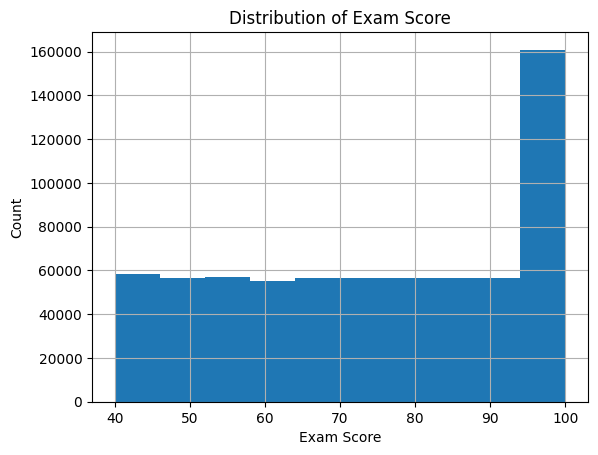

In [141]:
clean_data['Exam_Score'].hist()
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show

In [142]:
clean_data["Homework_Completion_%"].kurt()

np.float64(0.0331417042880231)

<function matplotlib.pyplot.show(close=None, block=None)>

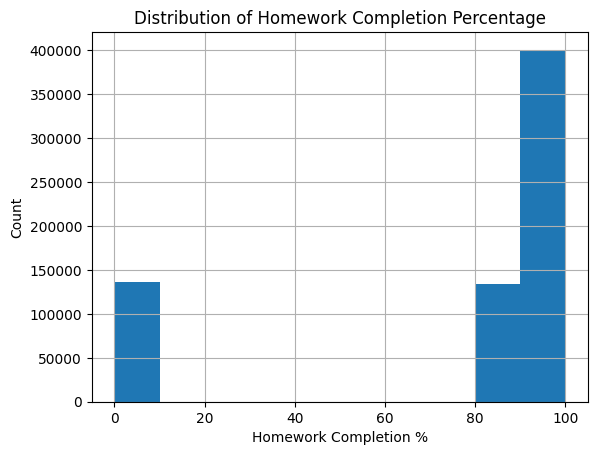

In [143]:
clean_data['Homework_Completion_%'].hist()
plt.title("Distribution of Homework Completion Percentage")
plt.xlabel("Homework Completion %")
plt.ylabel("Count")
plt.show

- The numeric columns show that no feature is heavily tailed, indicating a lower likelihood of extreme outliers.
- However, this will be further confirmed using a box-and-whisker plot

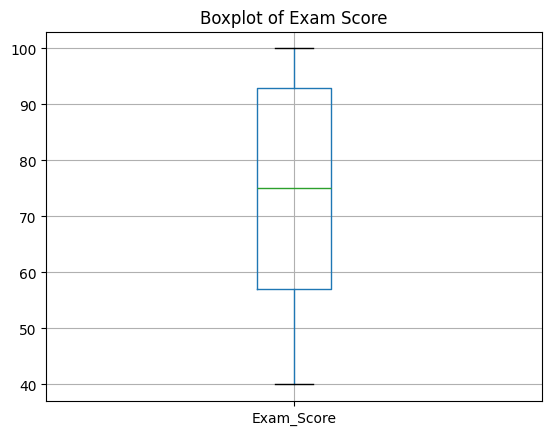

In [144]:
clean_data.boxplot(column='Exam_Score')
plt.title("Boxplot of Exam Score")
plt.show()

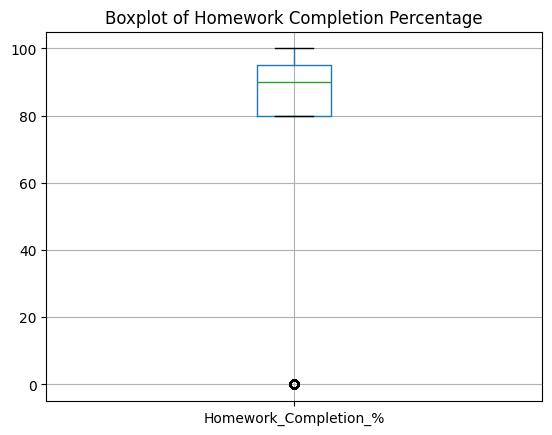

In [145]:
clean_data.boxplot(column='Homework_Completion_%')
plt.title("Boxplot of Homework Completion Percentage")
plt.show()

- Although the boxplot flags some values as outliers, these correspond to valid observations (mostly 80, 90, 95,100, with occasional 0).
- The clustered distribution and low kurtosis (0.03) indicate that these are not true outliers, so they are retained.

- Given that our data is now clean ,we will be moving to data analysis